# 02 — Dataset Inspection & Exploratory Data Analysis (EDA)
### AI Interview System — 100% Project-Owned ML Pipeline
This notebook performs exploratory data analysis using **Pandas & Seaborn**:
1. **`data.head()`**: Preview sample dataset rows and feature columns.
2. **`data.info()`**: Inspect schema types, non-null counts, and memory footprint.
3. **`data.describe()`**: Compute statistical distributions (mean, std, min, quartiles, max).
4. **`data.isnull().sum()`**: Tally missing values across all columns.
5. **`sns.heatmap(corr_matrix)`**: Visualize feature correlations (question length, answer length, difficulty, domain).
6. **Class & Domain Distribution**: Plot category breakdowns across difficulty tiers and technical domains.


In [5]:
# Cell 1: Environment Setup & Load DataFrame (`data`)
import os
import sys
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Auto-detect workspace root (supports Google Colab, local terminal, or notebooks/ subfolder)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    if Path('/content/ai-interview-system/ml-service').exists():
        WORKSPACE_DIR = Path('/content/ai-interview-system/ml-service')
    elif Path('/content/drive/MyDrive/ai-interview-system/ml-service').exists():
        WORKSPACE_DIR = Path('/content/drive/MyDrive/ai-interview-system/ml-service')
    else:
        WORKSPACE_DIR = Path(os.getcwd())
    print("[OK] Running in Google Colab:", WORKSPACE_DIR)
except ImportError:
    cwd = Path(os.getcwd())
    if cwd.name == "notebooks":
        WORKSPACE_DIR = cwd.parent
    elif (cwd / "ml-service").exists():
        WORKSPACE_DIR = cwd / "ml-service"
    else:
        WORKSPACE_DIR = cwd
    print("[OK] Running in local environment:", WORKSPACE_DIR)

WORKSPACE_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORKSPACE_DIR)
if str(WORKSPACE_DIR) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_DIR))
print(f"[OK] Working Directory set to: {WORKSPACE_DIR}")

RAW_DATASET_FILE = WORKSPACE_DIR / "dataset" / "raw" / "raw_interview_dataset.json"
FIGURES_EDA_DIR = WORKSPACE_DIR / "reports" / "figures" / "eda"
FIGURES_EDA_DIR.mkdir(parents=True, exist_ok=True)

with open(RAW_DATASET_FILE, "r", encoding="utf-8") as f:
    records = json.load(f)

# Load into Pandas DataFrame
data = pd.DataFrame(records)

# Feature engineering: compute text metrics and encoded numerical representations
data["q_char_len"] = data["question"].fillna("").astype(str).str.len()
data["q_word_count"] = data["question"].fillna("").astype(str).str.split().str.len()
data["a_char_len"] = data["answer"].fillna("").astype(str).str.len()
data["a_word_count"] = data["answer"].fillna("").astype(str).str.split().str.len()
data["difficulty_encoded"] = data["difficulty"].map({"Beginner": 1, "Intermediate": 2, "Advanced": 3}).fillna(2).astype(int)
data["domain_encoded"] = data["domain"].astype("category").cat.codes

print(f"Loaded DataFrame with shape: {data.shape} ({data.shape[0]} rows, {data.shape[1]} columns)")


[OK] Running in local environment: c:\Users\gihan\Documents\ai-interview-system\ml-service
[OK] Working Directory set to: c:\Users\gihan\Documents\ai-interview-system\ml-service
Loaded DataFrame with shape: (2291, 14) (2291 rows, 14 columns)


In [6]:
# Cell 2: data.head() — Dataset Preview
print("=== FIRST 5 ROWS (data.head()) ===")
data.head()


=== FIRST 5 ROWS (data.head()) ===


,id,domain,difficulty,input_prompt,question,answer,source,license,q_char_len,q_word_count,a_char_len,a_word_count,difficulty_encoded,domain_encoded
0,HF_ALI_00000,General Software Engineering,Beginner,General interview question,Why should we hire you?,Detailed technical explanation of Why should w...,huggingface:ali-alkhars/interviews,MIT / Open Data,23,5,57,9,1,4
1,HF_ALI_00001,General Software Engineering,Beginner,General interview question,Tell me about yourself.,Detailed technical explanation of Tell me abou...,huggingface:ali-alkhars/interviews,MIT / Open Data,23,4,57,8,1,4
2,HF_ALI_00002,Frontend Development,Beginner,Can you give me interview questions about Angu...,What is Angular Framework?,Detailed technical explanation of What is Angu...,huggingface:ali-alkhars/interviews,MIT / Open Data,26,4,60,8,1,3
3,HF_ALI_00003,Frontend Development,Intermediate,Could we do a mock interview?,What is the difference between AngularJS and A...,Detailed technical explanation of What is the ...,huggingface:ali-alkhars/interviews,MIT / Open Data,53,8,87,12,2,3
4,HF_ALI_00004,Frontend Development,Beginner,Could we do a mock interview?,What is TypeScript?,Detailed technical explanation of What is Type...,huggingface:ali-alkhars/interviews,MIT / Open Data,19,3,53,7,1,3


In [7]:
# Cell 3: data.info() — Dataset Schema & Data Types
print("=== DATASET INFO (data.info()) ===")
data.info()


=== DATASET INFO (data.info()) ===
<class 'pandas.DataFrame'>
RangeIndex: 2291 entries, 0 to 2290
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  2291 non-null   str  
 1   domain              2291 non-null   str  
 2   difficulty          2291 non-null   str  
 3   input_prompt        2291 non-null   str  
 4   question            2291 non-null   str  
 5   answer              2291 non-null   str  
 6   source              2291 non-null   str  
 7   license             2291 non-null   str  
 8   q_char_len          2291 non-null   int64
 9   q_word_count        2291 non-null   int64
 10  a_char_len          2291 non-null   int64
 11  a_word_count        2291 non-null   int64
 12  difficulty_encoded  2291 non-null   int64
 13  domain_encoded      2291 non-null   int8 
dtypes: int64(5), int8(1), str(8)
memory usage: 872.6 KB


In [8]:
# Cell 4: data.describe() — Statistical Summary
print("=== DESCRIPTIVE STATISTICS (data.describe()) ===")
data[["q_char_len", "q_word_count", "a_char_len", "a_word_count", "difficulty_encoded", "domain_encoded"]].describe()


=== DESCRIPTIVE STATISTICS (data.describe()) ===


,q_char_len,q_word_count,a_char_len,a_word_count,difficulty_encoded,domain_encoded
count,2291.000000,2291.000000,2291.000000,2291.000000,2291.000000,2291.000000
mean,57.382802,9.390659,91.382802,13.390659,1.703186,3.505893
std,42.733281,6.447821,42.733281,6.447821,0.670061,0.869842
min,11.000000,2.000000,45.000000,6.000000,1.000000,0.000000
25%,34.000000,6.000000,68.000000,10.000000,1.000000,3.000000
50%,47.000000,8.000000,81.000000,12.000000,2.000000,4.000000
75%,64.000000,11.000000,98.000000,15.000000,2.000000,4.000000
max,630.000000,100.000000,664.000000,104.000000,3.000000,6.000000


In [9]:
# Cell 5: data.isnull().sum() — Missing Values Check
print("=== MISSING VALUES COUNT (data.isnull().sum()) ===")
print(data.isnull().sum())


=== MISSING VALUES COUNT (data.isnull().sum()) ===
id                    0
domain                0
difficulty            0
input_prompt          0
question              0
answer                0
source                0
license               0
q_char_len            0
q_word_count          0
a_char_len            0
a_word_count          0
difficulty_encoded    0
domain_encoded        0
dtype: int64


Saved correlation heatmap to: c:\Users\gihan\Documents\ai-interview-system\ml-service\reports\figures\eda\correlation_heatmap.png


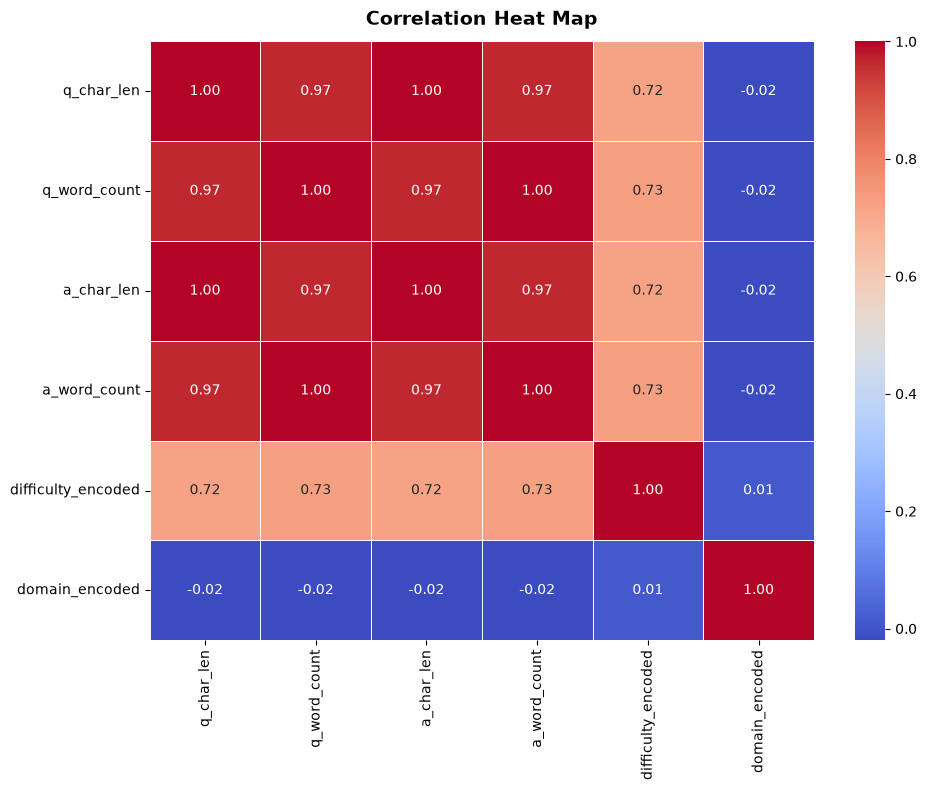

In [10]:
# Cell 6: Correlation Matrix & Heatmap
corr_metrix = data[["q_char_len", "q_word_count", "a_char_len", "a_word_count", "difficulty_encoded", "domain_encoded"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_metrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)
plt.title("Correlation Heat Map", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()

# Save figure to reports/figures/eda/
heat_path = FIGURES_EDA_DIR / "correlation_heatmap.png"
plt.savefig(heat_path, dpi=300)
print(f"Saved correlation heatmap to: {heat_path}")
plt.show()


Saved class distribution plot to: c:\Users\gihan\Documents\ai-interview-system\ml-service\reports\figures\eda\class_distribution.png


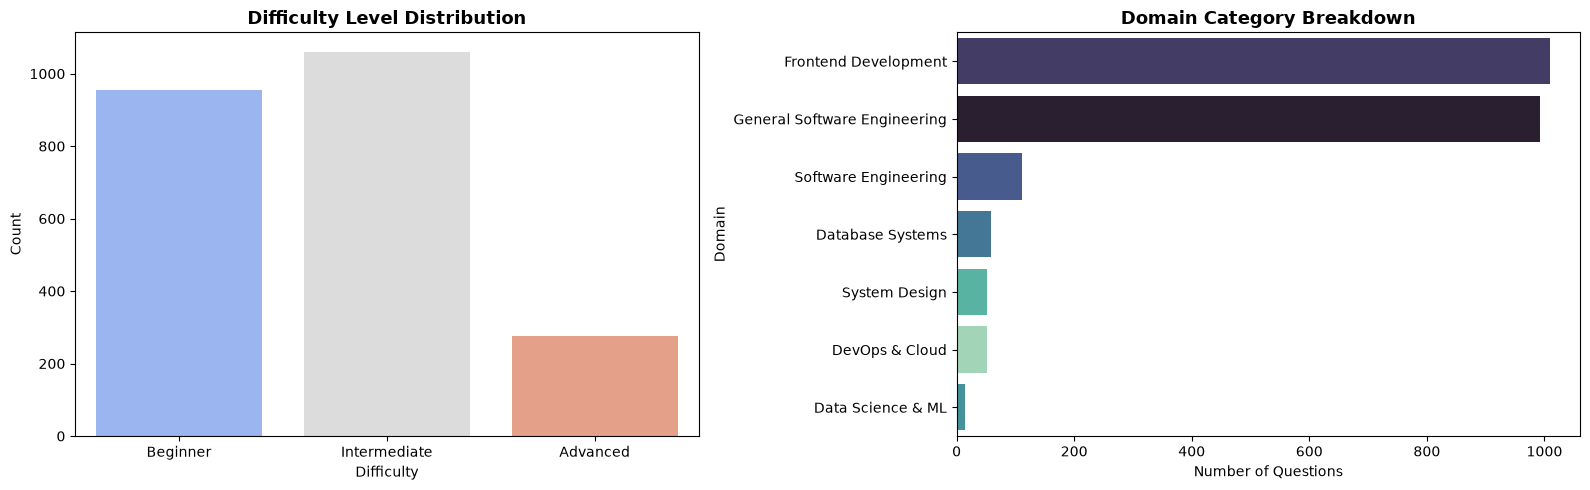

Stage 02 (EDA & Dataset Inspection) Completed Successfully.


In [11]:
# Cell 7: Category & Difficulty Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Difficulty distribution
sns.countplot(data=data, x="difficulty", order=["Beginner", "Intermediate", "Advanced"], palette="coolwarm", ax=axes[0], hue="difficulty", legend=False)
axes[0].set_title("Difficulty Level Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Difficulty")
axes[0].set_ylabel("Count")

# Domain distribution
domain_order = data["domain"].value_counts().index
sns.countplot(data=data, y="domain", order=domain_order, palette="mako", ax=axes[1], hue="domain", legend=False)
axes[1].set_title("Domain Category Breakdown", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Questions")
axes[1].set_ylabel("Domain")

plt.tight_layout()
dist_path = FIGURES_EDA_DIR / "class_distribution.png"
plt.savefig(dist_path, dpi=300)
print(f"Saved class distribution plot to: {dist_path}")
plt.show()

print("Stage 02 (EDA & Dataset Inspection) Completed Successfully.")
